# Scaling Laws Analysis
### Standard Parameterization vs µP


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COLORS = {
    "sp":  "#2563eb",   # blue
    "mup": "#dc2626",   # red
}

## Define Model Parameter Counts

In [13]:
MODEL_NAMES  = ["tiny", "small", "medium", "large", "xl"]
PARAM_COUNTS = [
    1_442_944,   # tiny
    3_639_744,   # small
    12_587_904,  # medium
    34_089_472,  # large
    88_886_016,  # xl
]

N = np.array(PARAM_COUNTS, dtype=float)

pd.DataFrame({"model": MODEL_NAMES, "n_params": PARAM_COUNTS}).style.format({"n_params": "{:,.0f}"})

,model,n_params
0,tiny,"1,442,944"
1,small,"3,639,744"
2,medium,"12,587,904"
3,large,"34,089,472"
4,xl,"88,886,016"


## SP Validation Losses

In [4]:
VAL_LOSS_SP = [
    1.6927,   # tiny
    1.6551,   # small
    1.4723,   # medium
    1.4479,   # large
    1.5580,   # xl
]

df_sp = pd.DataFrame({
    "model":    MODEL_NAMES,
    "n_params": PARAM_COUNTS,
    "val_loss_sp": VAL_LOSS_SP,
})
df_sp

,model,n_params,val_loss_sp
0,tiny,1442944,1.6927
1,small,3639744,1.6551
2,medium,12587904,1.4723
3,large,34089472,1.4479
4,xl,88886016,1.5580


## Evaluation Metrics: Wall-Clock Time, GPU Memory & Throughput

In [5]:
EPOCH_TIME_S   = [418.89, 387.07, 641.08, 1267.11, 2531.63]   # wall-clock seconds per epoch
GPU_MEMORY_GB  = [20465, 12146, 9071, 8402, 7953]   # peak GPU memory in GB
TOKENS_PER_SEC = [281111.7, 296399.3, 175166.8, 87428.2, 43423.0]   # average tokens/second

df_metrics = pd.DataFrame({
    "model":          MODEL_NAMES,
    "n_params":       PARAM_COUNTS,
    "epoch_time_s":   EPOCH_TIME_S,
    "gpu_memory_gb":  GPU_MEMORY_GB,
    "tokens_per_sec": TOKENS_PER_SEC,
})
df_metrics

,model,n_params,epoch_time_s,gpu_memory_gb,tokens_per_sec
0,tiny,1442944,418.89,20465,281111.7
1,small,3639744,387.07,12146,296399.3
2,medium,12587904,641.08,9071,175166.8
3,large,34089472,1267.11,8402,87428.2
4,xl,88886016,2531.63,7953,43423.0


## Fit Power Law to SP Scaling Data

Fit $L = a \cdot N^{-\alpha} + c$ to the SP validation losses using non-linear least squares.

In [6]:
def power_law(N, a, alpha, c):
    """L = a * N^(-alpha) + c"""
    return a * N ** (-alpha) + c


def fit_power_law(N, L, label=""):
    """Fit power law and return (popt, pcov). Prints a summary."""
    valid = [(n, l) for n, l in zip(N, L) if l is not None]
    if len(valid) < 3:
        print(f"[{label}] Not enough data points to fit (need ≥ 3, got {len(valid)}).")
        return None, None
    Nv, Lv = np.array([v[0] for v in valid]), np.array([v[1] for v in valid])
    try:
        popt, pcov = curve_fit(
            power_law, Nv, Lv,
            p0=[1.0, 0.1, min(Lv) * 0.9],
            bounds=([0, 0, 0], [np.inf, 2, np.inf]),
            maxfev=10_000,
        )
        a, alpha, c = popt
        perr = np.sqrt(np.diag(pcov))
        print(f"[{label}] a={a:.4f} ± {perr[0]:.4f}  α={alpha:.4f} ± {perr[1]:.4f}  c={c:.4f} ± {perr[2]:.4f}")
        return popt, pcov
    except RuntimeError as e:
        print(f"[{label}] Fit failed: {e}")
        return None, None


popt_sp, pcov_sp = fit_power_law(N, VAL_LOSS_SP, label="SP")

[SP] a=7682.9641 ± 120504.2968  α=0.7347 ± 1.1259  c=1.4801 ± 0.1121


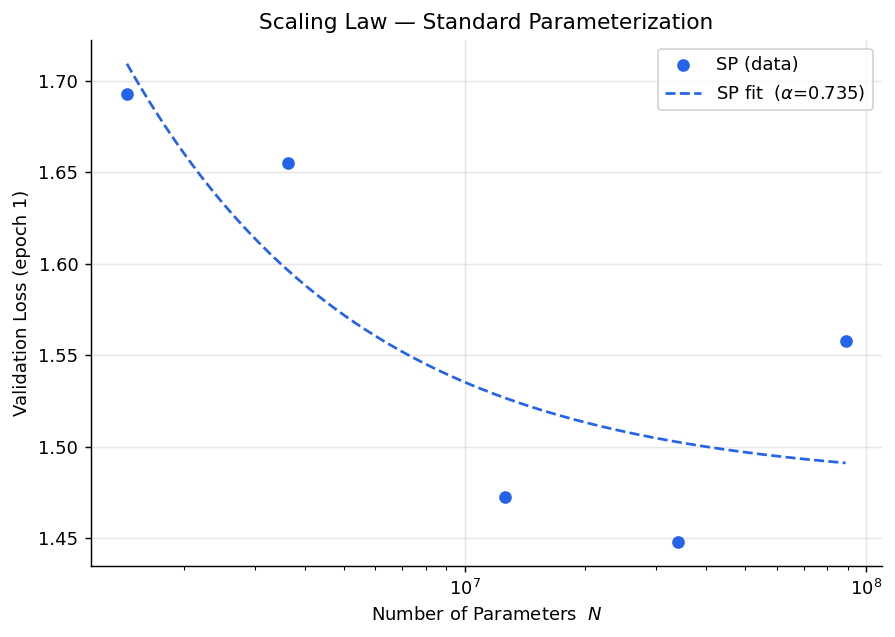

In [7]:
def plot_scaling_curve(ax, N, losses, popt, color, label, marker="o"):
    valid_idx = [i for i, l in enumerate(losses) if l is not None]
    Nv = N[valid_idx]
    Lv = np.array([losses[i] for i in valid_idx])
    ax.scatter(Nv, Lv, color=color, marker=marker, zorder=5, label=f"{label} (data)")
    if popt is not None:
        N_fit = np.logspace(np.log10(N.min()), np.log10(N.max()), 300)
        L_fit = power_law(N_fit, *popt)
        alpha = popt[1]
        ax.plot(N_fit, L_fit, color=color, linestyle="--",
                label=rf"{label} fit  ($\alpha$={alpha:.3f})")


fig, ax = plt.subplots(figsize=(7, 5))
plot_scaling_curve(ax, N, VAL_LOSS_SP, popt_sp, COLORS["sp"], "SP")

ax.set_xscale("log")
ax.set_xlabel("Number of Parameters  $N$")
ax.set_ylabel("Validation Loss (epoch 1)")
ax.set_title("Scaling Law — Standard Parameterization")
ax.legend()
plt.tight_layout()
plt.show()

## µP Validation Losses

In [8]:
VAL_LOSS_MUP = [
    1.7788,   # tiny
    1.6789,   # small
    1.6500,   # medium
    1.5993,   # large
    1.7682,   # xl
]

df_mup = pd.DataFrame({
    "model":       MODEL_NAMES,
    "n_params":    PARAM_COUNTS,
    "val_loss_mup": VAL_LOSS_MUP,
})
df_mup

,model,n_params,val_loss_mup
0,tiny,1442944,1.7788
1,small,3639744,1.6789
2,medium,12587904,1.6500
3,large,34089472,1.5993
4,xl,88886016,1.7682


## Fit Power Law to µP Scaling Data

In [9]:
popt_mup, pcov_mup = fit_power_law(N, VAL_LOSS_MUP, label="µP")

if popt_sp is not None and popt_mup is not None:
    delta = popt_mup[1] - popt_sp[1]
    direction = "steeper (better)" if delta > 0 else "shallower (worse)"
    print(f"\nΔα = α_µP − α_SP = {delta:+.4f}  →  µP scaling is {direction}")

[µP] a=223422514811.5219 ± 20989784532791.6602  α=2.0000 ± 6.6359  c=1.6699 ± 0.0545

Δα = α_µP − α_SP = +1.2653  →  µP scaling is steeper (better)


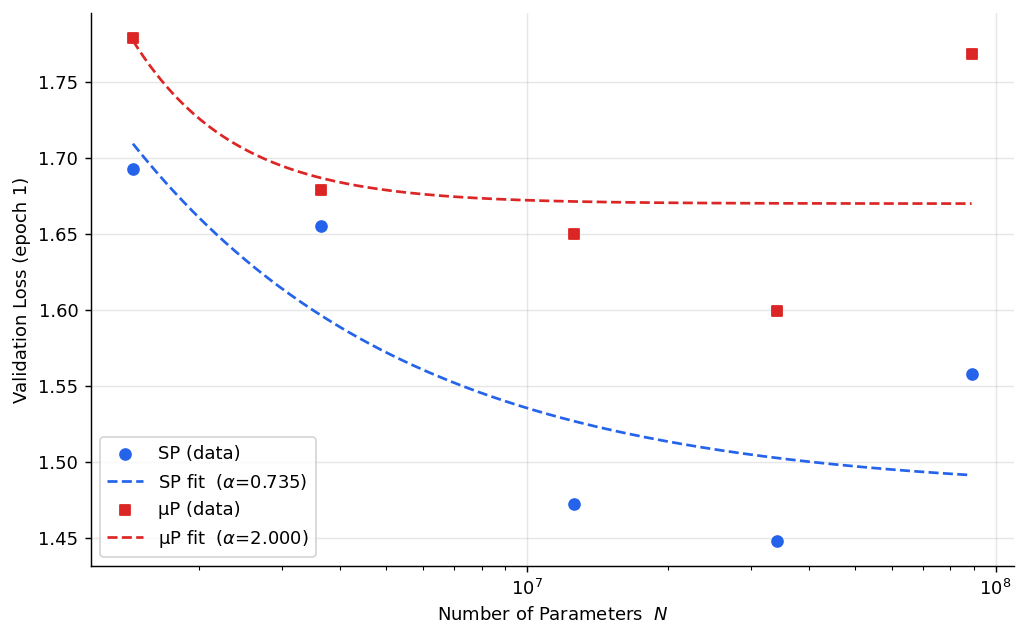

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_scaling_curve(ax, N, VAL_LOSS_SP,  popt_sp,  COLORS["sp"],  "SP",  marker="o")
plot_scaling_curve(ax, N, VAL_LOSS_MUP, popt_mup, COLORS["mup"], "µP", marker="s")

ax.set_xscale("log")
ax.set_xlabel("Number of Parameters  $N$")
ax.set_ylabel("Validation Loss (epoch 1)")
ax.set_title("Scaling Laws: Standard Parameterization vs µP")
ax.legend()
plt.tight_layout()
plt.show()

In [11]:
rows = []
for name, popt, pcov in [("SP", popt_sp, pcov_sp), ("µP", popt_mup, pcov_mup)]:
    if popt is not None:
        perr = np.sqrt(np.diag(pcov))
        rows.append({
            "Parameterization": name,
            "a":     f"{popt[0]:.4f} ± {perr[0]:.4f}",
            "α":     f"{popt[1]:.4f} ± {perr[1]:.4f}",
            "c":     f"{popt[2]:.4f} ± {perr[2]:.4f}",
        })
    else:
        rows.append({"Parameterization": name, "a": "—", "α": "—", "c": "—"})

pd.DataFrame(rows).set_index("Parameterization")

,a,α,c
Parameterization,,,
SP,7682.9641 ± 120504.2968,0.7347 ± 1.1259,1.4801 ± 0.1121
µP,223422514811.5219 ± 20989784532791.6602,2.0000 ± 6.6359,1.6699 ± 0.0545


In [ ]:
# Predict validation loss for a model 10x larger than the XL model
N_xl = N[-1]
N_target = N_xl * 10

# We use the µP fit as it yielded the steeper scaling curve
a, alpha, c = popt_mup

# Predict the loss
L_pred = power_law(N_target, a, alpha, c)

# Estimate uncertainty
J = np.array([
    N_target**(-alpha),
    -a * (N_target**(-alpha)) * np.log(N_target),
    1.0
])

variance = J.T @ pcov_mup @ J
std_err = np.sqrt(variance)

print(f"Largest Model (XL) Parameters: {N_xl:,.0f}")
print(f"Target Model (10x XL) Parameters: {N_target:,.0f}")
print(f"Predicted Validation Loss: {L_pred:.4f} ± {std_err:.4f}")

Largest Model (XL) Parameters: 88,886,016
Target Model (10x XL) Parameters: 888,860,160
Predicted Validation Loss: 1.6699 ± 0.0545
